# **Clase 25 - Embeddings**

MDS7202: Laboratorio de Programación Científica para Ciencia de Datos

## **Objetivos**

- Entender que son los modelos de Embeddings
- Machine learning
- RAG

## **Configuración Inicial 🧐**

Para esta clase necesitaremos configurar las credenciales de algunos servicios a utilizar, en específico:

### **Google AI Studio**

Usaremos `Google AI Studio` para habilitar el uso de LLMs y Embeddings de Google. Simplemente deben registrarse con su cuenta google y obtener su API KEY desde el siguiente enlace: [Google AI Studio](https://aistudio.google.com/app/u/1/apikey).

### **Tavily**

En paralelo, utilizaremos `Tavily` como motor de búsqueda para potenciar las respuestas de nuestros agentes. Tal como en el paso anterior, solo deben registrarse y obtener su API KEY desde el siguiente enlace: [Tavily](https://tavily.com/).

### **Configurar credenciales en ambiente**

Una vez se tienen todas las credenciales, pasamos a activarlas en nuestro ambiente local por medio del siguiente código:

In [ ]:
import getpass
import os

if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

O si les sale más fácil, también pueden hacerlo a través de un archivo **.env** (esto funciona mejor cuando trabajan desde sus máquinas locales).

Sólo debemos crearlo y escribir en él todas las credenciales:

```python
GOOGLE_API_KEY="<YOUR_GOOGLE_API_KEY>"
TAVILY_API_KEY="<YOUR_TAVILY_API_KEY>”
```

Luego, cargamos las credenciales al ambiente:

## **¿Qué son los Embeddings? 🤔**

En términos sencillos, un embedding es la representación vectorial de un fragmento de texto (una palabra, una frase o un documento completo) en forma de un vector denso de alta dimensión.

A diferencia de los enfoques tradicionales de NLP como Bag of Words o TF-IDF —que generan matrices gigantescas llenas de ceros (dispersas) y solo cuentan repeticiones de palabras—, los embeddings representan el **significado semántico** del texto en un espacio continuo.

El verdadero superpoder de los embeddings radica en una premisa matemática: si dos textos significan lo mismo, sus vectores estarán muy cerca el uno del otro en este espacio multidimensional, incluso si no comparten una sola palabra en común.

Un ejemplo intuitivo en 3DImagina que reducimos el universo semántico a solo 3 dimensiones o ejes conceptuales:
- Eje X: Realeza
- Eje Y: Género (Masculino / Femenino)
- Eje Z: Edad

Si graficamos las palabras "Rey", "Reina", "Hombre" y "Mujer", el modelo les asignará coordenadas de modo que, al aplicar aritmética vectorial básica, se cumpla una propiedad casi mágica:

$$\text{Vector}(\text{"Rey"}) - \text{Vector}(\text{"Hombre"}) + \text{Vector}(\text{"Mujer"}) \approx \text{Vector}(\text{"Reina"})$$

En los modelos actuales (como los de OpenAI o Google), este espacio no tiene 3 dimensiones, sino miles (por ejemplo, $d = 1536$ o $d = 3072$). Ningún ser humano puede visualizar un espacio de 3000 dimensiones, pero las herramientas de Machine Learning que tus alumnos ya conocen pueden calcular distancias, buscar patrones y agrupar estos vectores en milisegundos.

> 🤷 **Y pa qué me sirve?**

<center>
<img src='https://media1.giphy.com/media/v1.Y2lkPTc5MGI3NjExeGQ1Mm1nZzRqMW41bmJmbG1nMDN5NHN0ZGk3ZGYwdTlzcjBpNGM3YiZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/WRQBXSCnEFJIuxktnw/giphy.gif' width=450  />
</center>


Convertir el lenguaje humano en geometría y álgebra nos da un superpoder analítico: nos permite aplicar todo el arsenal del Machine Learning tradicional sobre el texto. Al transformar las palabras en vectores estructurados, dejamos de buscar coincidencias de caracteres exactos y empezamos a operar matemáticamente sobre el significado y las intentos, pero a una escala y con una profundidad semántica que antes era imposible. Esto abre la puerta a resolver problemas de negocio de una forma mucho más profunda, eficiente y escalable de lo que permite un simple chat.

Disponer de esta representación vectorial habilita una gran variedad de aplicaciones prácticas en Data Science:
- **Visualizar el significado**: Puedes proyectar miles de dimensiones en un gráfico bidimensional para mapear visualmente cómo se relacionan las ideas de un dataset.
- **Agrupar texto automáticamente**: Puedes aplicar algoritmos de agrupamiento para descubrir temáticas u opiniones ocultas en grandes volúmenes de documentos sin tener que leerlos.
- **Clasificar con alta eficiencia**: Puedes entrenar modelos tradicionales para categorizar correos, tickets o reseñas basándote en su contexto y no en palabras clave.
- Predecir valores continuos: Puedes usar el contenido de un texto como variables de entrada para algoritmos de regresión (por ejemplo, estimar el precio de una propiedad según su descripción escrita).
- **Hacer búsquedas inteligentes**: Puedes construir buscadores que encuentren el documento correcto respondiendo a lo que el usuario quiere decir, incluso si usa sinónimos o palabras completamente distintas.
- **Optimizar costos en producción**: Puedes resolver tareas específicas entrenando un modelo clásico sobre embeddings precalculados, lo cual es miles de veces más rápido, económico y robusto que hacer prompt engineering en un chatbot para cada petición.


**¡Manos a la obra!**

## 🕹️ **Jugando con embeddings**

Para utilizar modelos de embeddings, **Langchain** pone a nuestra disposición clases que permiten interactuar con modelos de diferentes proveedores. Por ejemplo, para embeddings de google, podemos usar la clase `GoogleGenerativeAIEmbeddings`.

A diferencia de los modelos de chat completion, los modelos de embeddings no tienen un método `invoke`. En su lugar existe el método `embed_query` para vectorizar un solo texto, y `embed_documents` para vectorizar múltiples textos en paralelo.

In [ ]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding_client = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
)

result = embedding_client.embed_query("Hola!")

In [2]:
type(result)

list

In [3]:
len(result)

3072

Por defecto, los modelos de `gemini-embeddings` generan embeddings de dimensión `3072`. Esa alta dimensionalidad permite capturar el significado del texto con el mayor detalle posible, aunque es verdad que para algunas aplicaciones puede ser demasiado alta.

Por suerte, Google implementa en sus modelos una técnica avanzada de Machine Learning llamada **Matryoshka Representation Learning (MRL)**, nombrada así en honor a las famosas muñecas rusas que se guardan una dentro de otra. El modelo es entrenado específicamente para que la información semántica más importante y densa del texto se concentre en los primeros componentes del vector. Esto significa que si decides configurar un tamaño menor mediante el parámetro output_dimensionality (como 768 o 512), la API no realiza ningún cálculo nuevo ni probabilístico; simplemente toma el vector original de 3072 y lo trunca. Para realizar esto desde la configuración de la clase, usar el parámetro `output_dimensionality`.

> ❓**Pregunta**: ¿Qué implica que sean vectores de significado?

Como se dijo anteriormente, el análisis del lenguaje anteriormente implicaba conteo de palabras, y 2 textos eran considerados similares si tenían las mismas palabras. Veamos cómo funciona esto con embeddings. A continuación tenemos 3 textos similares, ya sea en significado o porque tienen palabras parecidas.

In [4]:
textos_similares = [
    "La inflación y las tasas de interés afectan el bolsillo de los ciudadanos.",
    "La situación económica actual y el costo de la vida impactan directamente en el presupuesto familiar.",
    "Tengo 10 lucas en el bolsillo, pero no tengo interés en gastarlos en una tasa de café."
]

Usamos `embed_documents` para vectorizar múltiples documentos al mismo tiempo. Los transformamos a una matriz de numpy para poder operarlos más facilmente.

In [5]:
import numpy as np

vectores_similares = np.array(embedding_client.embed_documents(textos_similares))
vectores_similares.shape

(3, 3072)

Para comparar los vectores se pueden utilizar muchas métricas de similitud o distancia. Para embeddings, uno de los métodos más utilizados (que se relaciona con cómo fueron entrenados) es la **similitud coseno**, que mide la similitud de la _dirección_ en la que apuntan los embeddings.

$$\text{Similarity}(A,B)=\frac{A\cdot B}{\|A\|\|B\|}$$

In [6]:
def cosine_similarity(vec_a, vec_b):
    producto_punto = np.dot(vec_a, vec_b)
    norma_a = np.linalg.norm(vec_a)
    norma_b = np.linalg.norm(vec_b)

    similarity = producto_punto / (norma_a * norma_b)

    return similarity

# Comparamos todos con todos
for i in range(len(textos_similares)):
    for j in range(i + 1, len(textos_similares)):
        vec_a = vectores_similares[i]
        vec_b = vectores_similares[j]
        texto_a = textos_similares[i]
        texto_b = textos_similares[j]
        
        print(f"Texto '{texto_a[:20]}...' con texto '{texto_b[:20]}..', similitud: {cosine_similarity(vec_a, vec_b)}")


Texto 'La inflación y las t...' con texto 'La situación económi..', similitud: 0.8668759660347813
Texto 'La inflación y las t...' con texto 'Tengo 10 lucas en el..', similitud: 0.7741602557611503
Texto 'La situación económi...' con texto 'Tengo 10 lucas en el..', similitud: 0.74780907615557


A pesar de que el texto 3 tiene 2 palabras iguales al texto 1 y una palabra homónima (tasa vs taza), su embedding es menos similar a él que el embedding del texto 2 con el que no comparte ninguna palabra en común. 

> Ejercicio: Vamos a jugar con el significado de las palabras. Se les darán conjuntos de palabras. En cada conjunto habrá una palabra objetivo y 9 distractores. Su objetivo es encontrar una palabra de forma que la más similar del conjunto sea la palabra objetivo.
> 🚫 **Restricción** No pueden utilizar derivados o raices de la palabra objetivo (ej. para libertad no pueden usar libre, o para éxito no pueden usar exitoso)

In [ ]:
class JuegoDePalabras:
    def __init__(self, palabras):
        self.palabras = palabras
        self.embeddings_palabras = np.array(embedding_client.embed_documents(palabras))

    def palabra_mas_similar(self, query):
        embedding_query = np.array(embedding_client.embed_query(query))
        similarities = [
            cosine_similarity(embedding_query, embedding_palabra) 
            for embedding_palabra in self.embeddings_palabras
        ]
        return self.palabras[np.argmax(similarities)]


nivel_1 = JuegoDePalabras([
    "Éxito", "Dinero", "Fama", "Esfuerzo", "Trabajo", "Victoria", "Suerte", "Talento", "Ambición", "Negocio"
])

nivel_2 = JuegoDePalabras([
    "Justo", "Bueno", "Legal", "Correcto", "Honesto", "Equitativo", "Recto", "Moral", "Juez", "Ley"
])

nivel_3 = JuegoDePalabras([
    "Destino", "Futuro", "Tiempo", "Viaje", "Suerte", "Azar", "Fin", "Camino", "Muerte", "Vida"
])

nivel_4 = JuegoDePalabras([
    "Caos", "Desorden", "Confusión", "Ruido", "Destrucción", "Peligro", "Miedo", "Emergencia", "Desastre", "Problema"
])

nivel_5 = JuegoDePalabras([
    "Tiempo", "Reloj", "Calendario", "Pasado", "Futuro", "Espacio", "Distancia", "Velocidad", "Dimensión", "Infinito"
])

nivel_6 = JuegoDePalabras([
    "Arte", "Belleza", "Pintura", "Música", "Museos", "Cultura", "Estética", "Talento", "Diseño", "Creatividad"
])

nivel_7 = JuegoDePalabras([
    "Libertad", "Derecho", "Justicia", "Opción", "Decisión", "Voluntad", "Independencia", "Vuelo", "Cárcel", "Elección"
])

In [8]:
# Nivel 1: Encontrar la palabra 'Éxito'
palabra = "Ganar"
nivel_1.palabra_mas_similar(palabra)

'Éxito'

In [9]:
# Nivel 2: Encontrar la palabra 'Justo'
palabra = "Imparcial"
nivel_2.palabra_mas_similar(palabra)

'Justo'

In [11]:
# Nivel 3: Encontrar la palabra 'Destino'
palabra = "Direccion"
nivel_3.palabra_mas_similar(palabra)

'Destino'

In [ ]:
# Nivel 4: Encontrar la palabra 'Caos'
palabra = "TU_PALABRA"
nivel_4.palabra_mas_similar(palabra)

In [ ]:
# Nivel 5: Encontrar la palabra 'Tiempo'
palabra = "TU_PALABRA"
nivel_5.palabra_mas_similar(palabra)

In [ ]:
# Nivel 6: Encontrar la palabra 'Arte'
palabra = "TU_PALABRA"
nivel_6.palabra_mas_similar(palabra)

In [14]:
# Nivel 7: Encontrar la palabra 'Libertad'
palabra = "America"
nivel_7.palabra_mas_similar(palabra)

'Libertad'

## 🛠️ **Machine Learning con Embeddings**

<center>
<img src='https://media3.giphy.com/media/v1.Y2lkPTc5MGI3NjExdTVxbDR4cjZlbDJ2aWFhZDNvZ2YybmtzOHhhYTdqcTExbjdyMmYxOSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/AE2wKBTDYI54w9afj1/giphy.gif' width=450  />
</center>

El tener un vector altamente representativo del significado de un texto es muy útil. Tan así, que es posible ocuparlo en machine learning, ya sea de forma no supervisada como supervisada. Es decir, podemos ocupar el embedding para clasificar etiquetas o estimar valores asociados a textos, y también para clusterizar significados. Para esto vamos a tomar datos de **descripciones de ofertas laborales** con texto como features y aplicar casos de negocio útiles.

### 🏢 Procesando los datos

Cargamos los datos y exploramos brevemente. Vemos que tenemos las siguientes columnas:
- `title`: Título de la oferta laboral
- `description`: Descripción del empleo
- `max_salary`: Límite superior de lo que ofrece el empleo, en dólares anuales

In [15]:
import pandas as pd

df = pd.read_csv("job_postings.csv")
df.head()

,title,description,max_salary
0,Director of Human Resources and Administration,Employer: Urban RootsPosition: Director of Hum...,76000.0
1,"Director, Software Engineering",The Director of Software Engineering at FloQas...,275000.0
2,Route Sales Professional,req39031\n\nEmployment Type: Regular\n\nLocati...,65000.0
3,"Manager, Sales Marketing (Law)",GLG serves thousands of the world’s best compa...,77500.0
4,Electrical & Instrumentation Design Engineer,"Salary: $95,000 to $145,000\nWhat is your perf...",145000.0


Vemos que en total tenemos 1500 filas

In [16]:
df.shape

(1500, 3)

Para aplicar machine learning y diferentes técnicas de analítica a estos datos, primero debemos vectorizarlos. Acá tenemos varias opciones: si debemos elegir una columna de texto para vectorizar, hace más sentido vectorizar `description` ya que tiene información mucho más completa que `title`

Sin embargo, no tenemos por qué elegir una, nosotros podemos construir el texto que más nos haga sentido a vectorizar. En este caso, tiene sentido construir algo así:

```
Title: {title}

Description: {description}
```

De esta forma, se le da al modelo de embeddings contexto de qué representa cada texto.

In [17]:
texts_to_embed = "Title: " + df["title"] +"\n\nDescription: " + df["description"]
texts_to_embed = texts_to_embed.to_list()
texts_to_embed

['Title: Director of Human Resources and Administration\n\nDescription: Employer: Urban RootsPosition: Director of Human Resources and AdministrationReports to: Executive DirectorLocation: Austin, TXSchedule: Full-time, Monday through Friday, with some weekend days to flex for weekdays as needed Salary: $72,000-$76,000 (exempt), Benefits (see below)Preferred Start Date: June 25, 2024\nNote on how to apply: Please see See bottom of listing for full instructions, but inquiries through LinkedIn/messenger will not be considered.  Who we are:Urban Roots works with youth leaders to grow fresh food and build a community dedicated to achieving food equity. The only farm-based youth development and community impact organization in Austin, we have worked with over 600 youth through paid internships that support their growth as leaders. This past growing season, our staff, youth interns, and volunteers harvested over 119,000 servings of sustainably-grown produce on our farms in East and South Aus

Luego, para vectorizar usaremos un modelo de embeddings con dimensión 768. Es preferible no utilizar la dimensión completa de `3072`, ya que tendría el doble de dimensiones que filas por lo que los modelos tenderían a sobreajustarse.

In [18]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding_client = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001",
    output_dimensionality=768,
)

embeddings_jobs = []

Podemos utilizar una función como esta para calcular los embeddings de a varias llamadas, ya que la api de embeddings tiene límite de cantidad de textos que se pueden vectorizar simultaneamente.

In [ ]:
def paso_generacion_embeddings(embeddings_jobs, data, batch_size=25):
    data_to_embed = data[len(embeddings_jobs): len(embeddings_jobs) + batch_size]

    embedded_data = embedding_client.embed_documents(data_to_embed)

    embeddings_jobs.extend(embedded_data)
    print("Total textos procesados:", len(embeddings_jobs), "de", len(data))


paso_generacion_embeddings(embeddings_jobs, texts_to_embed)

🚫 **¡ALTO AHÍ!** 🚫

Lamentablemente, la versión gratuita de Google AI Studio tiene límites diarios para la cantidad de textos que se pueden vectorizar, los cuales son muy por debajo que la cantidad de datos que tenemos en la tabla 😕

Por esto, para los ejercicios a continuación pueden cargar los embeddings pre-calculados con el modelo `gemini-embeddings-001` en formato csv presentes en el archivo `job_postings_embeddings.csv`



In [19]:
df_embeddings = pd.read_csv("job_postings_embeddings.csv")
df_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
0,-0.017781,0.004428,0.004070,-0.062657,0.018812,0.014994,0.005695,0.031930,-0.004329,0.003498,...,-0.012428,-0.029144,0.003844,-0.020277,-0.018315,0.011135,0.020343,-0.004879,0.003664,0.014871
1,0.003127,0.007812,-0.008612,-0.084786,-0.010279,0.008353,0.009606,0.001701,0.025028,0.014091,...,-0.002567,-0.025431,0.007671,-0.021773,-0.000764,0.007463,0.019495,-0.006610,-0.002098,0.016992
2,-0.022887,0.028010,0.032160,-0.052052,0.002842,0.028356,-0.004813,0.029199,-0.028562,-0.019356,...,0.025864,-0.004503,0.017433,-0.023917,0.013681,0.013444,-0.001972,0.015571,0.004674,0.009471
3,-0.017973,0.000645,0.007126,-0.070583,0.008729,-0.012527,0.006117,0.003855,0.000699,0.014557,...,0.014701,-0.017694,-0.021523,-0.012653,0.028579,-0.014041,0.011173,0.013914,-0.014982,-0.010118
4,-0.016077,-0.033645,0.022492,-0.055756,0.001309,-0.009930,-0.006910,0.015266,0.005537,-0.008009,...,0.001186,-0.027320,0.005912,-0.013861,0.000856,-0.014017,-0.006889,0.016238,0.013305,-0.012485


### 📈 **Aprendizaje no supervisado**

Imaginemos que estos datos pertenecen a una **empresa de empleabilidad** como Linkedin. 

El área de analítica podría preguntarse sobre la **distribución de tipos de empleos** presentes en la plataforma. Es decir, que no tienen realmente visibilidad de qué tipos de empleos tienen, y de cada publicación solo poseen datos no estructurados, como la descripción. 

En base a esto, podrían perfectamente utilizar modelos _normales_ de chat completion con output estructurado para obtener, por ejemplo, el rubro o tipo de empleo según algún criterio. Sin embargo, para esto hay que primero explorar los datos para recién definir las categorías a usar para la clasificación.

Por esto, realizaremos **clustering** de los embeddings y posterior **reducción de dimensionalidad** y luego **visualización de datos** para ver qué agrupaciones se observan y cómoe estas se distribuyen se agrupan. Para la reducción de dimensionalidad ocuparemos **TSNE** que es una de las técnicas más avanzadas de reducción de dimensionalidad, para esto. Usaremos una perplexity baja, que propiciará las agrupaciones locales por sobre los patrones globales.

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(perplexity=20)

red_dim = tsne.fit_transform(df_embeddings)

Asignamos las dimensiones a la tabla original

In [21]:
df["tsne_1"] = red_dim[:, 0]
df["tsne_2"] = red_dim[:, 1]

df

,title,description,max_salary,tsne_1,tsne_2
0,Director of Human Resources and Administration,Employer: Urban RootsPosition: Director of Hum...,76000.0,-25.549747,-7.056062
1,"Director, Software Engineering",The Director of Software Engineering at FloQas...,275000.0,50.664124,11.134158
2,Route Sales Professional,req39031\n\nEmployment Type: Regular\n\nLocati...,65000.0,18.634752,-49.814564
3,"Manager, Sales Marketing (Law)",GLG serves thousands of the world’s best compa...,77500.0,7.392996,-21.838501
4,Electrical & Instrumentation Design Engineer,"Salary: $95,000 to $145,000\nWhat is your perf...",145000.0,16.531651,51.634018
...,...,...,...,...,...
1495,"Scientific Director, Medical Communications",This role is responsible for the strategic dir...,170000.0,0.089587,13.455837
1496,Junior Litigation Associate,LHH is assisting one of our favorite repeat cl...,260000.0,-61.863689,-3.118798
1497,"Accounting and Finance Consulting Manager, Fun...",We are the leading provider of professional se...,190400.0,-47.709599,-19.460083
1498,Staff Accountant,About usBrowne Trading Company is a wholesale/...,62000.0,-40.124622,-39.949547


In [22]:
import plotly.express as px

px.scatter(
    df, 
    x="tsne_1", 
    y="tsne_2", 
    color="max_salary",
    hover_data={
        "title": True,
        "tsne_1": False, 
        "tsne_2": False, 
        "max_salary": False,
    },
    width=1000, 
    height=800
)

Observamos que se obtienen ciertas agrupaciones. La gracia de este enfoque es que permite encontrar categorías "suaves". Esto es, sin tener que clasificar "duramente" por rubro, podemos encontrar trabajos que están _entre medio_ de 2 agrupaciones, y que efectivamente el trabajo no pertenece claramente a un solo rubro.

 Procedemos con clustering con el algoritmo **KMeans** para identificar clusters, esta vez sí de forma categórica.

In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)

clusters = kmeans.fit_predict(df_embeddings)
clusters

array([8, 3, 9, ..., 5, 5, 5], shape=(1500,), dtype=int32)

Guardamos en la tabla

In [24]:
df["cluster"] = clusters
df["cluster"] = df["cluster"].astype(str)

df

,title,description,max_salary,tsne_1,tsne_2,cluster
0,Director of Human Resources and Administration,Employer: Urban RootsPosition: Director of Hum...,76000.0,-25.549747,-7.056062,8
1,"Director, Software Engineering",The Director of Software Engineering at FloQas...,275000.0,50.664124,11.134158,3
2,Route Sales Professional,req39031\n\nEmployment Type: Regular\n\nLocati...,65000.0,18.634752,-49.814564,9
3,"Manager, Sales Marketing (Law)",GLG serves thousands of the world’s best compa...,77500.0,7.392996,-21.838501,1
4,Electrical & Instrumentation Design Engineer,"Salary: $95,000 to $145,000\nWhat is your perf...",145000.0,16.531651,51.634018,2
...,...,...,...,...,...,...
1495,"Scientific Director, Medical Communications",This role is responsible for the strategic dir...,170000.0,0.089587,13.455837,1
1496,Junior Litigation Associate,LHH is assisting one of our favorite repeat cl...,260000.0,-61.863689,-3.118798,4
1497,"Accounting and Finance Consulting Manager, Fun...",We are the leading provider of professional se...,190400.0,-47.709599,-19.460083,5
1498,Staff Accountant,About usBrowne Trading Company is a wholesale/...,62000.0,-40.124622,-39.949547,5


Visualizamos

In [25]:
import plotly.express as px

px.scatter(
    df, 
    x="tsne_1", 
    y="tsne_2", 
    color="cluster",
    hover_data={
        "title": True,
        "tsne_1": False, 
        "tsne_2": False, 
        "max_salary": False,
    },
    width=1000, 
    height=800
)

Observamos que ciertos rubros se separan bien del resto, como legal, contaduría, software, etc.

¡Nuestra exploración dió resultado! Sin embargo, si bien observamos agrupaciones con sentido, el modelo todavía podría estar utilizando cosas como el estilo de escritura para agrupar los trabajos, o otras dimensiones semánticas como 'Qué tan serio' es el trabajo, 'qué tan urgente' se necesita un empleado, el 'nivel de responsabilidad' del trabajo, etc.

### 📈 Un trucazo semántico

<center>
<img src='https://media1.giphy.com/media/v1.Y2lkPTZjMDliOTUyOGt5cnBlY2ZkeXkxcGp3cXhmMDJpNDdqZnVsNnFoOTM4OWZjdWZiMyZlcD12MV9naWZzX3NlYXJjaCZjdD1n/l0IylOPCNkiqOgMyA/giphy.gif' width=450  />
</center>
Nos gustaría poder diferenciar la dimensión "rubro" de las otras dimensiones semánticas. Para esto, podemos utilizar **aritmética de embeddings** para obtener cuales son las dimensiones del embedding más relacionadas a el rubro del empleo.

Para esto, tomaremos un saco de palabras 

> ⚠️ **ADVERTENCIA**: Este método es _artesanal_, y si bien funciona, debe ser validado, iterado y contrastado si se busca aplicarlo en soluciones de la industria

In [26]:
palabras_rubros = [
    "Agricultura",
    "Ganadería",
    "Silvicultura",
    "Pesca",
    "Minería",
    "Manufactura",
    "Construcción",
    "Energía",
    "Telecomunicaciones",
    "Transporte",
    "Logística",
    "Comercio",
    "Finanzas",
    "Seguros",
    "Inmobiliaria",
    "Turismo",
    "Gastronomía",
    "Entretenimiento",
    "Deportes",
    "Tecnología",
    "Educación",
    "Salud",
    "Ciencia",
    "Cultura",
    "Marketing",
    "Legal",
    "Consultoría",
    "Gobierno",
    "Defensa",
    "Seguridad",
    "Medioambiente",
    "ONGs",
]

In [27]:
embeddings_rubros = embedding_client.embed_documents(palabras_rubros)

In [28]:
np.array(embeddings_rubros).shape

(32, 768)

np.float64(0.3496410659148428)

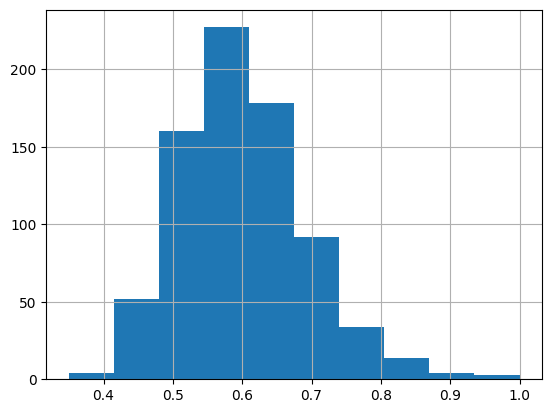

In [29]:
std_rubros = np.std(embeddings_rubros, axis=0)
std_rubros = std_rubros / std_rubros.max()
std_rubros = std_rubros
pd.Series(std_rubros).hist()
std_rubros.min()

In [30]:
df_embeddings_ponderados = df_embeddings * std_rubros

In [32]:
red_dim = tsne.fit_transform(df_embeddings)

df["pond_tsne_1"] = red_dim[:, 0]
df["pond_tsne_2"] = red_dim[:, 1]

clusters = kmeans.fit_predict(df_embeddings)

df["pond_cluster"] = clusters
df["pond_cluster"] = df["pond_cluster"].astype(str)


In [33]:
px.scatter(
    df, 
    x="pond_tsne_1", 
    y="pond_tsne_2", 
    color="pond_cluster",
    hover_data={
        "title": True,
        "pond_tsne_1": False, 
        "pond_tsne_2": False, 
        "max_salary": False,
    },
    width=1000, 
    height=800
)

¡Aparentemente, nuestra nueva agrupación y visualización tiene más sentido!

Finalmente, podemos identificar nuestos clusters utilizando un modelo de chat completion para describirlos. En primer lugar juntamos todos los títulos por cluster.

In [36]:
titulos_clusters = {
    cluster: "\n- ".join(df.loc[df["pond_cluster"] == cluster, "title"].tolist())
    for cluster in df["pond_cluster"].unique()
}
titulos_clusters

{'6': "Director of Human Resources and Administration\n- Landscape Remote Sensing Scientist\n- Disaster Preparedness Program Representative 2 (NY HELPS)\n- Municipal Attorney - Lateral\n- Georgia Senior Organizing Manager\n- Research Associate II or Associate Scientist, Cancer Biology\n- Criminal Defense Attorney\n- Associate Attorney\n- Director of Health and Social Services\n- Editor of Investigations\n- Associate Attorney\n- Paralegal - PIP\n- Bacteriology Scientist II\n- Strategic & Sustainability Planner (9165)\n- Executive Director\n- Assistant Director of Financial Aid\n- Associate Director of Auxiliaries\n- Paralegal\n- Automotive Window Tint, PPF, and Vehicle Wrap installer\n- Protein Expression Scientist\n- Executive Officer + Citizens' Law Enforcement Review Board\n- Transportation Security Officer\n- Legal IP Assistant\n- Assistant Teaching Professor in Business Information & Analytics\n- Administrative Support Coordinator - Administrative Office of the Courts (AOC)\n- Seni

Luego generamos una chain con un modelo con output estructurado para evitar que el modelo rellene con texto innecesario.

In [34]:
from langchain_core.prompts import PromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

from pydantic import BaseModel, Field


llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0, 
)

prompt_template = """
Eres un agente de resumen semántico. Tu tarea es encontrar la categoría a la cual pertenecen las
ofertas laborales. Recibirás una lista de títulos de ofertas laborales y tu tarea es determinar
la categoría a la que pertenecen todos o la gran mayoría de los títulos de ofertas laborales.

# Títulos de ofertas laborales:
{titulos}
"""

prompt = PromptTemplate.from_template(prompt_template)

class CategoriaTrabajos(BaseModel):
    categoria: str = Field(description="Término breve con la categoría o rubro al que pertenecen los empleos")

structured_model = llm.with_structured_output(CategoriaTrabajos)

chain = prompt | structured_model

Aplicamos la chain a cada lista de títulos

In [37]:
nombres_clusters = {
    cluster: chain.invoke(titulos).categoria
    for cluster, titulos in titulos_clusters.items()
}

In [38]:
nombres_clusters

{'6': 'Servicios Profesionales y Administrativos',
 '8': 'Ingeniería de Software y Tecnología',
 '4': 'Ventas y Desarrollo de Negocios',
 '5': 'Gestión y Estrategia Corporativa',
 '0': 'Ingeniería y Construcción',
 '9': 'Salud y Servicios Médicos',
 '3': 'Gestión de Operaciones y Administración',
 '1': 'Tecnología de la Información',
 '7': 'Contabilidad y Finanzas',
 '2': 'Servicios Financieros y Administrativos'}

Renombramos los clusters y luego podemos visualizar.

In [39]:
df["rubro"] = df["pond_cluster"].replace(nombres_clusters)
df

,title,description,max_salary,tsne_1,tsne_2,cluster,pond_tsne_1,pond_tsne_2,pond_cluster,rubro
0,Director of Human Resources and Administration,Employer: Urban RootsPosition: Director of Hum...,76000.0,-25.549747,-7.056062,8,-26.251795,-17.977013,6,Servicios Profesionales y Administrativos
1,"Director, Software Engineering",The Director of Software Engineering at FloQas...,275000.0,50.664124,11.134158,3,52.223114,29.091745,8,Ingeniería de Software y Tecnología
2,Route Sales Professional,req39031\n\nEmployment Type: Regular\n\nLocati...,65000.0,18.634752,-49.814564,9,20.020363,-42.421619,4,Ventas y Desarrollo de Negocios
3,"Manager, Sales Marketing (Law)",GLG serves thousands of the world’s best compa...,77500.0,7.392996,-21.838501,1,-1.758881,-16.520628,5,Gestión y Estrategia Corporativa
4,Electrical & Instrumentation Design Engineer,"Salary: $95,000 to $145,000\nWhat is your perf...",145000.0,16.531651,51.634018,2,31.653303,10.066044,0,Ingeniería y Construcción
...,...,...,...,...,...,...,...,...,...,...
1495,"Scientific Director, Medical Communications",This role is responsible for the strategic dir...,170000.0,0.089587,13.455837,1,-1.480327,1.887722,5,Gestión y Estrategia Corporativa
1496,Junior Litigation Associate,LHH is assisting one of our favorite repeat cl...,260000.0,-61.863689,-3.118798,4,-50.998966,-42.485203,6,Servicios Profesionales y Administrativos
1497,"Accounting and Finance Consulting Manager, Fun...",We are the leading provider of professional se...,190400.0,-47.709599,-19.460083,5,-45.367367,4.558400,7,Contabilidad y Finanzas
1498,Staff Accountant,About usBrowne Trading Company is a wholesale/...,62000.0,-40.124622,-39.949547,5,-53.516544,-15.060238,7,Contabilidad y Finanzas


In [40]:
px.bar(
    df["rubro"],
    color_discrete_sequence=['red'],
    width = 900,
    height = 600
)


In [41]:
px.scatter(
    df, 
    x="pond_tsne_1", 
    y="pond_tsne_2", 
    color="rubro",
    hover_data={
        "title": True,
        "pond_tsne_1": False, 
        "pond_tsne_2": False, 
        "max_salary": False,
    },
    width=1000, 
    height=800
)

### 🧩 **Aprendizaje supervisado**

Si bien analizar los textos con técnicas no supervisadas es útil, el verdadero poder de los embeddings para ML recae en utilizarlos para aprendizaje supervisado.

#### ¿Entrenamiento de clasificador con embeddings o inferencia directa con un LLM?

Si se requiere _clasificar_ en base a texto, podría diseñarse un prompt bien ajustado que obtenga la clase que necesitamos. En el ejemplo anterior, se podría haber utilizado una chain con output estructurado para simplemente preguntarle a un LLM cual es la categoría o rubro de cada trabajo. ¿Por qué habría de usar embeddings para esto?

La razón es que usar LLMs para obtener la categoría directamente solo puede funcionar si en el texto mismo está la respuesta. En el caso anterior, al mirar la descripción o incluso solo el título, se podría inferir a qué rubro pertenece. Pero existen casos donde esto no puede inferirse directamente del texto pero sí poseemos de ejemplos que permiten encontrar la tendencia mediante machine learning

> 🎯 **Caso de negocio:** Supongamos que quieres construir un sistema que evalúe proyectos de tecnología según qué tan probable es que se vendan. Podrías pasarle el PDF con la propuesta del proyecto a un LLM podrías y con eso evaluar diferentes dimensiones. El LLM podría decirte que un proyecto es sólido o que está bien estructurado, etc. etc. Pero que esté bien hecho según el LLM no implica que se va a vender. En vez de eso, si se entrena un modelo de clasificación en base a embeddings dandole ejemplos de proyectos que ganaron o no ganaron, el modelo evaluará las dimensiones que **realmente impactaron** en la probabilidad de venta. Quizá tenían que tener un uso del lenguaje más simple, quizá debía ser más barato, etc.

Esto se potencia mucho más en el caso de la **regresión**, ya que un modelo con structured output en escencia no puede estimar un número, mientras que un modelo regresor en base a embeddings podrá encontrar la relación matemática entre el significado del texto y el valor a predecir.

#### 💵 Prediciendo salarios

Volviendo al ejemplo de valores de propiedades, vemos que en el dataset hay una columna de **max_salary** que podríamos predecir en base al texto. Entender la relación entre la descripción del texto y el salario podría permitir construir un buen modelo de **pricing** que permita que los empleadores puedan comparar y ajustar su oferta. De esta forma, al crear una oferta de empleo, podría aparecer el mensaje _"Para este tipo de empleos otros empleadores pagan X"_ que permita tener una referencia, lo cual haría que esta plataforma sea más atractiva.

Comenzamos realizando holdout.

In [42]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_embeddings, df["max_salary"], test_size = 0.2
)

Entrenamos 3 modelos con diferentes niveles de complejidad. 

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_pred_train = lr.predict(X_train)

print("r2_score train:", r2_score(y_train, y_pred_train))
print("r2_score test:", r2_score(y_test, y_pred))

r2_score train: 0.885278699044867
r2_score test: 0.3476808798510981


In [44]:
from sklearn.linear_model import Lasso

la = Lasso(alpha=10)

la.fit(X_train, y_train)

y_pred = la.predict(X_test)
y_pred_train = la.predict(X_train)

print("r2_score train:", r2_score(y_train, y_pred_train))
print("r2_score test:", r2_score(y_test, y_pred))

r2_score train: 0.7636975392941954
r2_score test: 0.610339382279202


In [45]:
from sklearn.linear_model import Ridge

ri = Ridge(alpha=0.1)

ri.fit(X_train, y_train)

y_pred = ri.predict(X_test)
y_pred_train = ri.predict(X_train)

print("r2_score train:", r2_score(y_train, y_pred_train))
print("r2_score test:", r2_score(y_test, y_pred))

r2_score train: 0.7738114362013124
r2_score test: 0.6092718000725497


In [46]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=250, max_depth=20)


rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_pred_train = rf.predict(X_train)

print("r2_score train:", r2_score(y_train, y_pred_train))
print("r2_score test:", r2_score(y_test, y_pred))

r2_score train: 0.9174416059672204
r2_score test: 0.35623900927071517


In [47]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=1000, max_depth = 1, max_features = 0.3)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
y_pred_train = gb.predict(X_train)

print("r2_score train:", r2_score(y_train, y_pred_train))
print("r2_score test:", r2_score(y_test, y_pred))

r2_score train: 0.921602449462859
r2_score test: 0.512459521355201


## 🔍 **Búsqueda inteligente**

A continuación, nos moveremos hacia otra de las grandes aplicaciones de los embeddings: La **Búsqueda Semántica**

La búsqueda **semántica o inteligente** representa una evolución crítica. La búsqueda tradicional funciona como un filtro rígido de texto: si buscas la palabra "médico", el sistema ignorará los documentos que digan "doctor" o "terapeuta". La búsqueda inteligente resuelve esto convirtiendo el texto en vectores dentro de un mapa conceptual. El sistema ya no busca letras idénticas, sino significados y contextos equivalentes, procesando miles de documentos en milisegundos.

En nuestro caso, consideremos que la se busca habilitar un buscador inteligente en la página del portal de empleabilidad, de forma que los usuarios puedan encontrar su empleo ideal de forma mucho más eficiente. Para esto, aplicaremos el enfoque de embeddings para comparar y agrupar ofertas de empleo según su verdadero perfil técnico. Al vectorizar las descripciones de las vacantes, se realiza un match de similitud que va más allá del título del cargo. El modelo analiza el núcleo de las responsabilidades y competencias requeridas, lo que permite buscar de una forma _descriptiva_ un empleo y hacer match.

Para esto, construiremos una clase que servirá como buscador semántico.

In [50]:
import json

class BusquedaSemántica:
    def __init__(
        self, 
        documentos: list[dict], 
        embeddings: np.array, 
        embedding_model: GoogleGenerativeAIEmbeddings | None=None
    ):
        # Documentos es la info que vamos a encontrar. Podría ser un DataFrame de pandas, pero un
        # json es mucho más flexible y profesional
        self.documentos = documentos
        # Embeddings es la representación semántica de la info
        self.embeddings = embeddings
        # Servicio de embeddings
        self.embedding_model = embedding_model
    
    def search(self, query: str, max_results=10):
        q_embedding = self.embedding_model.embed_query(query)

        similitudes = np.dot(self.embeddings, q_embedding)
        similitudes = similitudes / np.linalg.norm(self.embeddings, axis=1)
        similitudes = similitudes / np.linalg.norm(q_embedding)

        order = np.argsort(-similitudes)

        results = [
            {
                "result": self.documentos[i],
                "score": similitudes[i].item()
            }
            for i in order[:max_results]
        ]

        return results
    
    def prettyprint(self, results: list[dict]):
        print(json.dumps(results, indent=4))

In [51]:
documentos = [
    {
        "Título": row["title"],
        "Descripción": row["description"],
        "Salario Máximo (USD/y)": row["max_salary"]
    }
    for _, row in df.iterrows()
]

documentos[:2]

[{'Título': 'Director of Human Resources and Administration',
  'Descripción': 'Employer: Urban RootsPosition: Director of Human Resources and AdministrationReports to: Executive DirectorLocation: Austin, TXSchedule: Full-time, Monday through Friday, with some weekend days to flex for weekdays as needed Salary: $72,000-$76,000 (exempt), Benefits (see below)Preferred Start Date: June 25, 2024\nNote on how to apply: Please see See bottom of listing for full instructions, but inquiries through LinkedIn/messenger will not be considered.  Who we are:Urban Roots works with youth leaders to grow fresh food and build a community dedicated to achieving food equity. The only farm-based youth development and community impact organization in Austin, we have worked with over 600 youth through paid internships that support their growth as leaders. This past growing season, our staff, youth interns, and volunteers harvested over 119,000 servings of sustainably-grown produce on our farms in East and S

In [53]:
buscador = BusquedaSemántica(
    documentos=documentos, 
    embeddings=df_embeddings.to_numpy(),
    embedding_model=embedding_client
)

In [58]:
buscador.prettyprint(buscador.search("Calculus", max_results=5))

[
    {
        "result": {
            "T\u00edtulo": "Math Interventionist",
            "Descripci\u00f3n": "Role Overview:\n\nMathematics Instructional Coach/Interventionist:\n\nCollege Achieve Public Schools- Central is seeking 2 math interventionist, one for elementary school and one for the middle school. \n\nA teacher at College Achieve Charter School will provide students rigorous and relevant\n\nlearning activities and experiences designed to prepare each student to excel at a top college or\n\nuniversity. This position is critical in building strong relationships with our students in order to best\n\nmeet their individual needs and further the mission of College Achieve.\n\nMathematics Instructional Coach/Interventionist to support teachers and students in implementing effective instructional practices aligned with New Jersey standards. The ideal candidate will have a strong background in mathematics education, instructional coaching, and a passion for supporting educators i

## 📖 **Retrieval Augmented Generation (RAG)**

La clase anterior vimos que se puede inyectar contexto al prompt de un chatbot, permitiendo que este responda preguntas sobre información presente en algun documento sin necesidad de que el modelo haya sido entrenado con esa información. Sin embargo, esto implica inyectar una cantidad enorme de tokens en nuestro prompt. Si bien los modelos más modernos soportan ventanas gigantescas de contexto, es posible que el modelo de respuestas imprecisas al sobrecargar el prompt. Además, aumenta tanto la latencia como el costo de tokens. 

Tiene más sentido solo inyectar los "trozos" de texto que sí tienen o podrían tener la respuesta a la pregunta que realiza el usuario. Por suerte, acabamos de ver que los embeddings permiten obtener una medida de similitud del significado de dos textos, por lo que podemos apalancarnos de esto para solamente traer los trozos de texto con significado similar a la pregunta del usuario.

**Retrieval Augmented Generation (RAG)** es una técnica para **ampliar el conocimiento** de los modelos de lenguaje grandes (LLMs) con **datos adicionales**, usualmente provenientes de **fuentes externas**. Si bien podemos hacer RAG con cualquier tipo de información externa, para esta sección nos concentraremos en hacer RAG sobre **documentos PDF**. En otras palabras, estaremos **nutriendo a nuestro LLM** con la información contenida en uno o más **documentos con extensión .pdf**.

<center>
<img src='https://raw.githubusercontent.com/MDS7202/MDS7202/main/recursos/2024-01//LLM/rag-framework.webp' width=450/>
</center>

### **¿Cómo funciona?**

La idea principal de esta solución es **responder la pregunta del usuario usando sólo los fragmentos de texto relevantes** para la pregunta en cuestión.

Con esto en consideración, para implementar una solución RAG sobre documentos PDF debemos pasar por 2 grandes etapas:

**1. Indexing**: Es el proceso por el cual **transformamos nuestros documentos** (.pdf) a **representaciones vectoriales**. Este es un paso que **se realiza sólo una vez**, pero fudamental para recuperar los fragmentos de texto relevantes.

 A su vez, para indexar un documento es necesario pasar por los siguientes pasos:
 - **Load**: **Ingesta del documento** al ambiente de trabajo (e.g: lectura y almacenamiento en strings).
 - **Split**: **Separación del documento en chunks de texto**. Chunks muy grandes pueden diluir la información necesaria para responder, chunks muy chicos pueden inducir a que se pierda el contexto.
 - **Embed**: Cada uno de los **chunks generados se transforman en representaciones vectoriales**, los cuales tienen la capacidad de almacenar la semántica, sintaxis y el contexto del chunk. Para esto, se utilizan modelos de lenguaje especializados en este tipo de transformaciones.
 - **Store**: Con los documentos vectorizados, **se almacenan estas representaciones** en una *vector store*.

<center>
<img src='https://mintcdn.com/langchain-5e9cc07a/I6RpA28iE233vhYX/images/rag_indexing.png?w=840&fit=max&auto=format&n=I6RpA28iE233vhYX&q=85&s=1838328a870c7353c42bf1cc2290a779' width=700/>
</center>

**2. Retrieval and Generation**: Es el proceso en la que proporcionamos información al LLM para que responda de manera acorde. Consta de las siguientes etapas:
- **Retrieve**: Proceso por el cual **se buscan los *top k* chunks más relevantes a la pregunta**. Para lograr esto, se utilizan técnicas de recuperación de información.
- **Generate**: **Se entregan los *top k*** chunks al LLM y **se responde la pregunta** del usuario.

<center>
<img src='https://mintcdn.com/langchain-5e9cc07a/I6RpA28iE233vhYX/images/rag_retrieval_generation.png?w=840&fit=max&auto=format&n=I6RpA28iE233vhYX&q=85&s=67fe2302e241fc24238a5df1cf56573d' width=700/>
</center>

Ya que conocemos el funcionamiento básico de una solución RAG, pasemos a ilustrar esto con un ejemplo. Para esto, construiremos un RAG a partir del reporte del [Estado Climático Global 2025](https://library.wmo.int/records/item/69807-state-of-the-global-climate-2025) realizado por la [Organización Metereológica Mundial](https://library.wmo.int/).

Primero instalamos las librerias necesarias:

In [59]:
!uv add langchain_community pypdf cryptography faiss-cpu ipywidgets

Resolved 219 packages in 3ms
Audited 214 packages in 1.59s


### **Indexing**

Recordando los pasos descritos al principio de esta sección, la primera tarea para implementar una solución RAG es **indexar los documentos**.  

#### **Load**

Ya que nuestro documento es de extensión .pdf, comenzaremos **ingestando el documento** usando `PyPDFLoader` (pueden consultar más loaders disponibles en la siguiente [página](https://python.langchain.com/docs/integrations/document_loaders/)):

In [60]:
from langchain_community.document_loaders import PyPDFLoader

pdf_path = "WMO-1391-2025_en.pdf"

loader = PyPDFLoader(pdf_path) # inicializar loader de PDF

docs = loader.load() # cargar documento
docs

C:\Users\Legion4\AppData\Local\Temp\ipykernel_31340\4043279191.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


[Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 0, 'page_label': '1'}, page_content='State of  \nthe Global \nClimate \n2025\nWMO-No. 1391'),
 Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 1, 'page_label': '2'}, page_content='WMO-No. 1391\n© World Meteorological Organization, 2026\nThe right of publication in print, electronic and any other form and in any language is reserved by WMO.  \nShort extracts from WMO publications may be reproduced without authorization, provided that the complete  \nsource is clearly indicated. Editorial correspondence 

In [61]:
len(docs) # noten como se genera una lista de 46 elementos, en este caso cada elemento es una página

46

In [62]:
docs[0] # cada elemento es del tipo Document, el cual posee el contenido de cada página

Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 0, 'page_label': '1'}, page_content='State of  \nthe Global \nClimate \n2025\nWMO-No. 1391')

In [63]:
print(docs[15].page_content)

16
State of the Global Climate 2025
State of the indicator
Data on glacier mass balance – the amount of mass gained or lost by glaciers   
– for the 2024/2025 hydrological year (September–August) are not yet finalized, 
but observations from 155 of the ~170 glaciers that are reported annually to the 
World Glacier Monitoring Service indicate that 2024/2025 was another year of 
extremely negative mass balance worldwide (Figure 6). 
Exceptionally negative mass balances were recorded in Iceland (which had its 
warmest year on record) and along the Pacific coast of North America.
Overall mass balance in 2024/2025 as estimated from a set of reference glaciers 
was among the five lowest glacier mass balances on record (1950-2025) and less 
negative than the record loss in 2022/2023. The 2024/2025 mass balance was 
close to the average for the preceding three years, 2021/2022 to 2023/2024, which 
saw the largest negative three-year mass balance on record. This continues 
a trend of accelerate

#### **Split**

Después de haber ingestado el documento, el siguiente paso es dividir cada documento en chunks de texto más pequeños. Para eso usaremos `RecursiveCharacterTextSplitter` (nuevamente, pueden consultar otros tipos de splitters en el siguiente [link](https://python.langchain.com/v0.1/docs/modules/data_connection/document_transformers/)):

In [64]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200) # inicializamos splitter
splits = text_splitter.split_documents(docs) # dividir documentos en chunks
splits[:5]

[Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 0, 'page_label': '1'}, page_content='State of  \nthe Global \nClimate \n2025\nWMO-No. 1391'),
 Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 1, 'page_label': '2'}, page_content='WMO-No. 1391\n© World Meteorological Organization, 2026\nThe right of publication in print, electronic and any other form and in any language is reserved by WMO.  \nShort extracts from WMO publications may be reproduced without authorization, provided that the complete  \nsource is clearly indicated. Editorial correspondence 

In [66]:
splits[10] # cada elemento es un Document, esta vez con menos contenido que en el paso anterior

Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 4, 'page_label': '5'}, page_content='continued increase in energy.\nAnother 3% of the excess energy warms and melts ice. In a global set of reference glaciers \nwith long-term measurements, eight of the ten most negative annual glacier mass \nbalances since 1950 have occurred since 2016. The ice sheets on Antarctica and Greenland \nhave both lost significant mass since satellite records began. \nThe extent of sea ice in the Arctic has decreased in all seasons since satellite \nmeasurements began in 1979, and the annual maximum extent in 2025 was the lowest or \nsecond lowest in the observed records. Sea-ice extent around Antarctica showed a small \nlong-term increase until 2015, but since then, extents throughout the ann

In [67]:
len(splits) # noten como ahora contamos con 124 chunks (pues 1 página contiene más de 1 chunk)

124

In [68]:
splits

[Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 0, 'page_label': '1'}, page_content='State of  \nthe Global \nClimate \n2025\nWMO-No. 1391'),
 Document(metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 1, 'page_label': '2'}, page_content='WMO-No. 1391\n© World Meteorological Organization, 2026\nThe right of publication in print, electronic and any other form and in any language is reserved by WMO.  \nShort extracts from WMO publications may be reproduced without authorization, provided that the complete  \nsource is clearly indicated. Editorial correspondence 

#### **Embed & Store**

Con los documentos separados en chunks, pasamos ahora a transformarlos a *embeddings*. Para esto simplemente ocupamos embeddings de Google a través de `GoogleGenerativeAIEmbeddings` (de nuevo).

Por el lado del vector store, usaremos `FAISS` (pueden revisar más opciones en este [link](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/)).

⚠️ **Cuidado:** Esto muy probablemente topará con tus límites de uso de modelo de embeddings si tienes la api gratuita de google ai studio. Para ejecutar una versión a prueba de límites de uso, proceder a la siguiente celda

In [69]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import FAISS

embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001") # inicializamos los embeddings
vectorstore = FAISS.from_documents(documents=splits, embedding=embedding) # vectorizacion y almacenamiento
vectorstore

KeyboardInterrupt: 

Ejecutar esto generalmente traerá problemas con los límites de tokens por minuto y requests por minuto de la api gratuita de Google Ai Studio. Para evitarlos, podemos procesar de a uno los textos y esperar 1 segundo entre procesamiento.

Si quieren saltarse todo esto, simplemente pueden cargar la base de conocimientos directamente desde archivo con el código de la celda subsiguiente

In [ ]:
import asyncio
from tqdm.notebook import tqdm
from langchain_community.vectorstores import FAISS
from langchain_google_genai import GoogleGenerativeAIEmbeddings

embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001") # inicializamos los embeddings

async def crear_faiss_con_pausa(documentos, embeddings):
    # 1. Inicializar el índice con el primer documento
    db = FAISS.from_documents([documentos[0]], embeddings)
    
    # 2. Agregar el resto uno a uno con pausa de 1 segundo
    for doc in tqdm(documentos[1:], desc="Indexando documentos"):
        await asyncio.sleep(1)
        db.add_documents([doc])
        
    return db

vectorstore = await crear_faiss_con_pausa(splits, embedding)

Luego podemos guardar nuestra vectorstore para no perder los datos procesados.

In [ ]:
vectorstore.save_local("faiss_index")

Acá podemos cargarla directamente sin tener que realizar todo este procesamiento.

In [72]:
from langchain_community.vectorstores import FAISS

embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001") # inicializamos los embeddings

# Load the index back, passing the SAME embeddings model used to create it
vectorstore = FAISS.load_local(
    "faiss_index", 
    embedding, 
    allow_dangerous_deserialization=True
)

### **Retrieval and Generation**

Con los documentos indexados, el siguiente paso es **habilitar que nuestro LLM pueda conseguir la información de los documentos** para responder preguntas.

#### **Retrieve**

Para esto, el primer paso es habilitar nuestro *vector store* para buscar los documentos más relevantes. Para esto, simplemente usamos el método `.as_retriever`:

In [73]:
retriever = vectorstore.as_retriever(
    search_type="similarity", # método de búsqueda
    search_kwargs={"k": 5}, # n° documentos a recuperar
)

retriever

VectorStoreRetriever(tags=['FAISS', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x000001D785DB17F0>, search_kwargs={'k': 5})

Con esto, podemos probar nuestro retriever:

In [74]:
question = "Cual es el estado actual del progreso del cambio climático?" # pregunta
relevant_documents = retriever.invoke(question) # top k documentos relevantes a la pregunta
relevant_documents

[Document(id='d9fee4e8-6616-4eb7-b51a-ee300f75e3f4', metadata={'producer': 'Adobe PDF Library 15.0', 'creator': 'Adobe InDesign 15.0 (Macintosh)', 'creationdate': '2026-03-26T17:48:36+01:00', 'moddate': '2026-03-26T17:49:08+01:00', 'trapped': '/False', 'source': 'WMO-1391-2025_en.pdf', 'total_pages': 46, 'page': 4, 'page_label': '5'}, page_content='5\nState of the Global Climate 2025\nThe temperature of the Earth changes in response to the rate at which energy enters and \nleaves the Earth system. Increasing concentrations of greenhouse gases in the atmosphere \nsuch as carbon dioxide, methane and nitrous oxide, all of which reached their highest \nlevel in 800 000 years in 2024 (the last year for which we have consolidated global figures), \nreduce the rate at which energy leaves the Earth system. This imbalance – the Earth’s \nenergy imbalance, a new indicator in this year’s report – leads to an accumulation of \nexcess energy. \nOne of the longest observational records of climate ch

Noten como la información relevante está almaenada en el atributo **page_content**:

In [75]:
relevant_documents[0].page_content

'5\nState of the Global Climate 2025\nThe temperature of the Earth changes in response to the rate at which energy enters and \nleaves the Earth system. Increasing concentrations of greenhouse gases in the atmosphere \nsuch as carbon dioxide, methane and nitrous oxide, all of which reached their highest \nlevel in 800 000 years in 2024 (the last year for which we have consolidated global figures), \nreduce the rate at which energy leaves the Earth system. This imbalance – the Earth’s \nenergy imbalance, a new indicator in this year’s report – leads to an accumulation of \nexcess energy. \nOne of the longest observational records of climate change is that of global mean \nnear-surface temperature. The past three years are the three warmest years in the  \n176-year combined land and ocean observational record. The year 2025 is the second or \nthird warmest year, depending on the dataset used, slightly cooler than the record warmth \nof 2024, due in part to the transition from El Niño at 

Como solo nos interesa ese atributo, podemos definir la función `format_docs` para procesar los chunks:

In [76]:
def format_docs(docs):
    return "\n\n".join(f"# Contexto #{i + 1}:\n{doc.page_content}" for i, doc in enumerate(docs))

print(format_docs(relevant_documents))

# Contexto #1:
5
State of the Global Climate 2025
The temperature of the Earth changes in response to the rate at which energy enters and 
leaves the Earth system. Increasing concentrations of greenhouse gases in the atmosphere 
such as carbon dioxide, methane and nitrous oxide, all of which reached their highest 
level in 800 000 years in 2024 (the last year for which we have consolidated global figures), 
reduce the rate at which energy leaves the Earth system. This imbalance – the Earth’s 
energy imbalance, a new indicator in this year’s report – leads to an accumulation of 
excess energy. 
One of the longest observational records of climate change is that of global mean 
near-surface temperature. The past three years are the three warmest years in the  
176-year combined land and ocean observational record. The year 2025 is the second or 
third warmest year, depending on the dataset used, slightly cooler than the record warmth 
of 2024, due in part to the transition from El Niño at

Finalmente, `LangChain` nos permite unir todos estos pasos en una **chain**:

In [77]:
retriever_chain = retriever | format_docs # chain
print(retriever_chain.invoke("Cual es el estado actual del progreso del cambio climático?"))

# Contexto #1:
5
State of the Global Climate 2025
The temperature of the Earth changes in response to the rate at which energy enters and 
leaves the Earth system. Increasing concentrations of greenhouse gases in the atmosphere 
such as carbon dioxide, methane and nitrous oxide, all of which reached their highest 
level in 800 000 years in 2024 (the last year for which we have consolidated global figures), 
reduce the rate at which energy leaves the Earth system. This imbalance – the Earth’s 
energy imbalance, a new indicator in this year’s report – leads to an accumulation of 
excess energy. 
One of the longest observational records of climate change is that of global mean 
near-surface temperature. The past three years are the three warmest years in the  
176-year combined land and ocean observational record. The year 2025 is the second or 
third warmest year, depending on the dataset used, slightly cooler than the record warmth 
of 2024, due in part to the transition from El Niño at

#### **Generation**

Con el retriever ya listo, la única pieza faltante es **entregar los documentos relevantes al LLM** para que pueda responder de mejor manera.

Para esto, primero definiremos un **template** para con las instrucciones a seguir:

In [ ]:
from langchain_core.prompts import PromptTemplate

# noten como ahora existe el parámetro de context!
rag_template = '''
Eres un asistente experto en ciencias medioambientales y tu especialidad es el panorama actual climático.
Tu único rol es contestar preguntas del usuario a partir de información relevante que te sea proporcionada.
Responde siempre de la forma más completa posible y usando toda la información entregada.
Responde sólo lo que te pregunten a partir de la información relevante, NUNCA inventes una respuesta.

Información relevante: {context}
Pregunta: {question}
Respuesta útil:
'''

rag_prompt = PromptTemplate.from_template(rag_template)

Finalmente, condensamos todo en una chain para recuperar información relevante y responder al mismo tiempo:

In [80]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0, 
)


rag_chain = (
    {
        "context": retriever_chain, # context lo obtendremos del retriever_chain
        "question": RunnablePassthrough(), # question pasará directo hacia el prompt
    }
    | rag_prompt # prompt con las variables question y context
    | llm # llm recibe el prompt y responde
    | StrOutputParser() # recuperamos sólo la respuesta
)

question = "Cuantos grados ha disminuido la temperatura en los ultimos años?"
response = rag_chain.invoke(question)
print(response)

Basado en la información proporcionada, no existe evidencia de que la temperatura global haya disminuido en los últimos años. Por el contrario, los datos indican lo siguiente:

*   **Tendencia de calentamiento:** Los últimos once años (2015–2025) han sido los once años más cálidos registrados. Además, los últimos tres años (2023–2025) han sido los tres más cálidos en todos los conjuntos de datos analizados.
*   **Temperatura en 2025:** La temperatura media global cerca de la superficie en 2025 fue 1,43 °C ± 0,13 °C superior al promedio preindustrial (1850–1900). Aunque fue una cifra inferior al récord histórico de 2024 (que alcanzó 1,55 °C ± 0,13 °C), esto se atribuye al cambio de condiciones de un fuerte fenómeno de El Niño a principios de 2024 a condiciones de La Niña débil al inicio y final de 2025, y no a una disminución general de la temperatura.
*   **Enfriamiento a escala centenaria:** La única área del mundo que ha experimentado un enfriamiento en una escala de tiempo centenari